In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [13]:
PATH = "../outputs/figuras"

TRAIN_FRESH = os.path.join(PATH, "freshoranges")
TRAIN_ROTTEN = os.path.join(PATH, "rottenoranges")

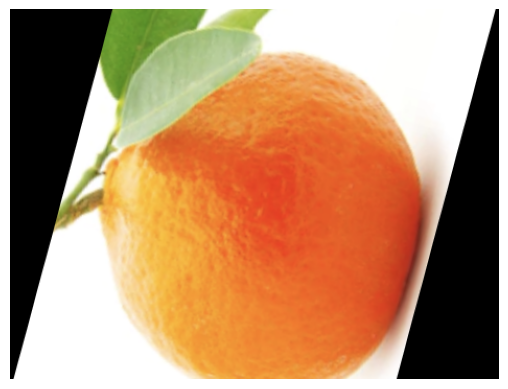

In [14]:
arquivo = os.listdir(TRAIN_FRESH)[0]

img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [15]:
print("Fresh:", len(os.listdir(TRAIN_FRESH)))
print("Rotten:", len(os.listdir(TRAIN_ROTTEN)))
print(img_rgb.shape)

Fresh: 1466
Rotten: 1595
(354, 468, 3)


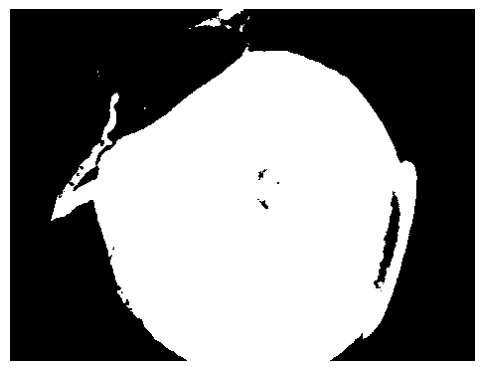

In [16]:
hsv = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)

lower = np.array([5, 50, 50])
upper = np.array([35, 255, 255])

mask = cv2.inRange(hsv,lower,upper)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

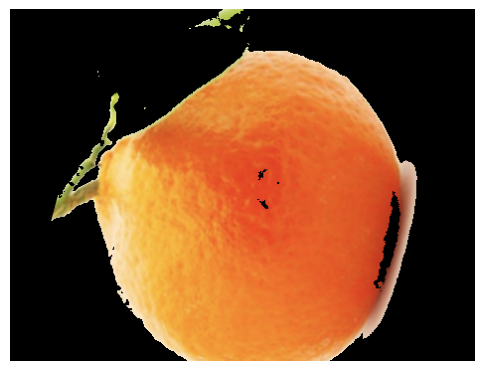

In [17]:
resultado = cv2.bitwise_and(img_rgb,img_rgb,mask=mask)

plt.figure(figsize=(6,6))
plt.imshow(resultado)
plt.axis("off")
plt.show()

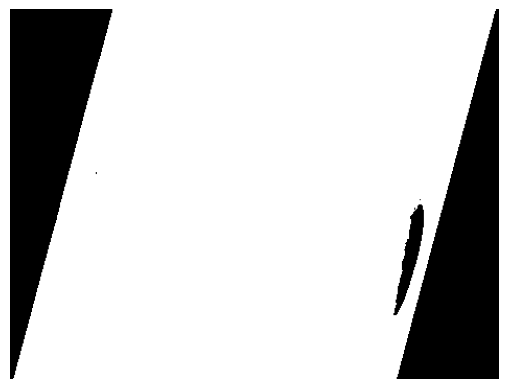

In [18]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

_, mask_otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_otsu, cmap='gray')
plt.axis("off")
plt.show()

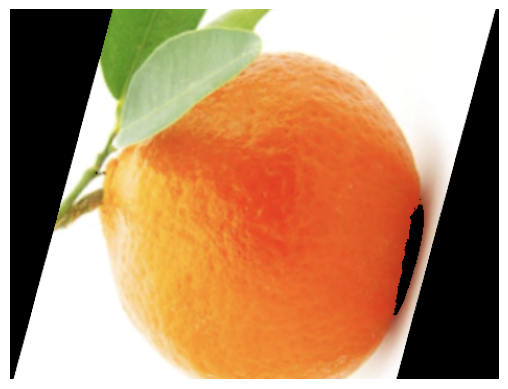

In [19]:
resultado_otsu = cv2.bitwise_and(img_rgb,img_rgb,mask=mask_otsu)

plt.imshow(resultado_otsu)
plt.axis("off")
plt.show()

In [20]:
def compare_segmentation(img_rgb, titulo=""):

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    lower = np.array([5, 50, 50])
    upper = np.array([35, 255, 255])

    mask_hsv = cv2.inRange(hsv, lower, upper)

    result_hsv = cv2.bitwise_and(img_rgb,img_rgb,mask=mask_hsv)

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    _, mask_otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    result_otsu = cv2.bitwise_and(img_rgb,img_rgb,mask=mask_otsu)

    fig, ax = plt.subplots(2, 3, figsize=(12, 8))

    fig.suptitle(titulo, fontsize=14)

    ax[0,0].imshow(img_rgb)
    ax[0,0].set_title("Original")
    ax[0,0].axis("off")

    ax[0,1].imshow(mask_hsv, cmap="gray")
    ax[0,1].set_title("Máscara HSV")
    ax[0,1].axis("off")

    ax[0,2].imshow(result_hsv)
    ax[0,2].set_title("Resultado HSV")
    ax[0,2].axis("off")

    ax[1,0].imshow(img_rgb)
    ax[1,0].set_title("Original")
    ax[1,0].axis("off")

    ax[1,1].imshow(mask_otsu, cmap="gray")
    ax[1,1].set_title("Máscara Otsu")
    ax[1,1].axis("off")

    ax[1,2].imshow(result_otsu)
    ax[1,2].set_title("Resultado Otsu")
    ax[1,2].axis("off")

    plt.tight_layout()
    plt.show()

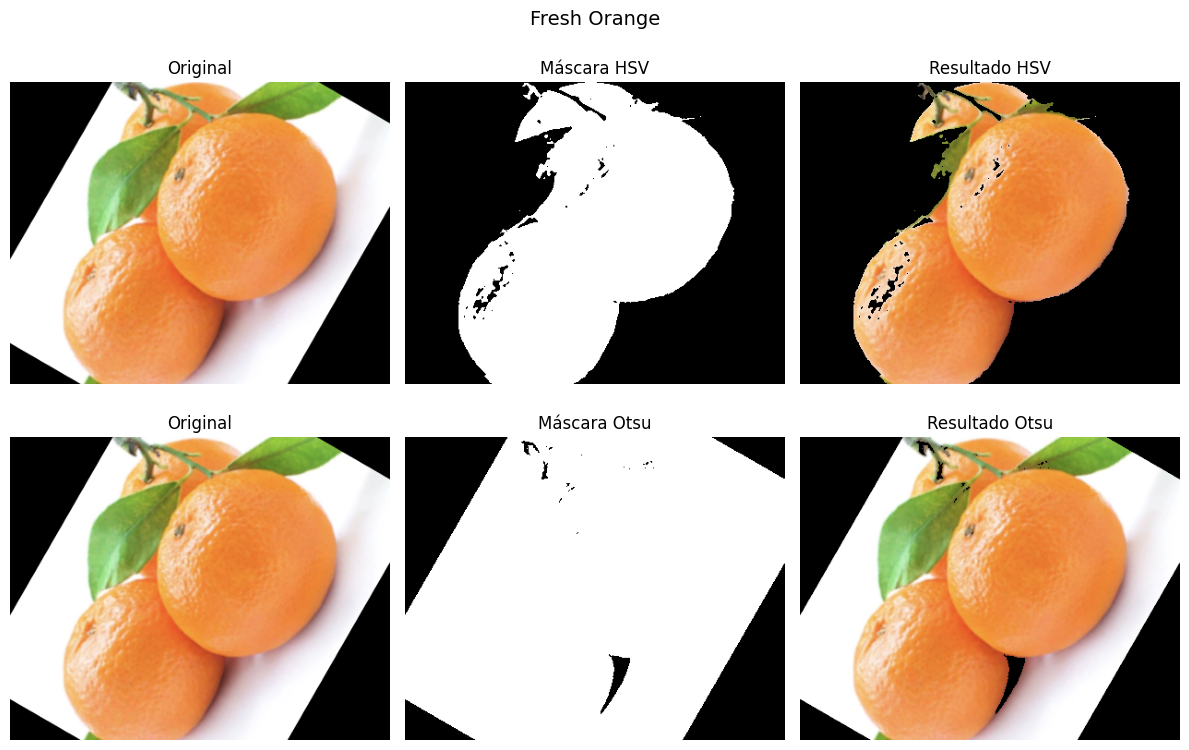

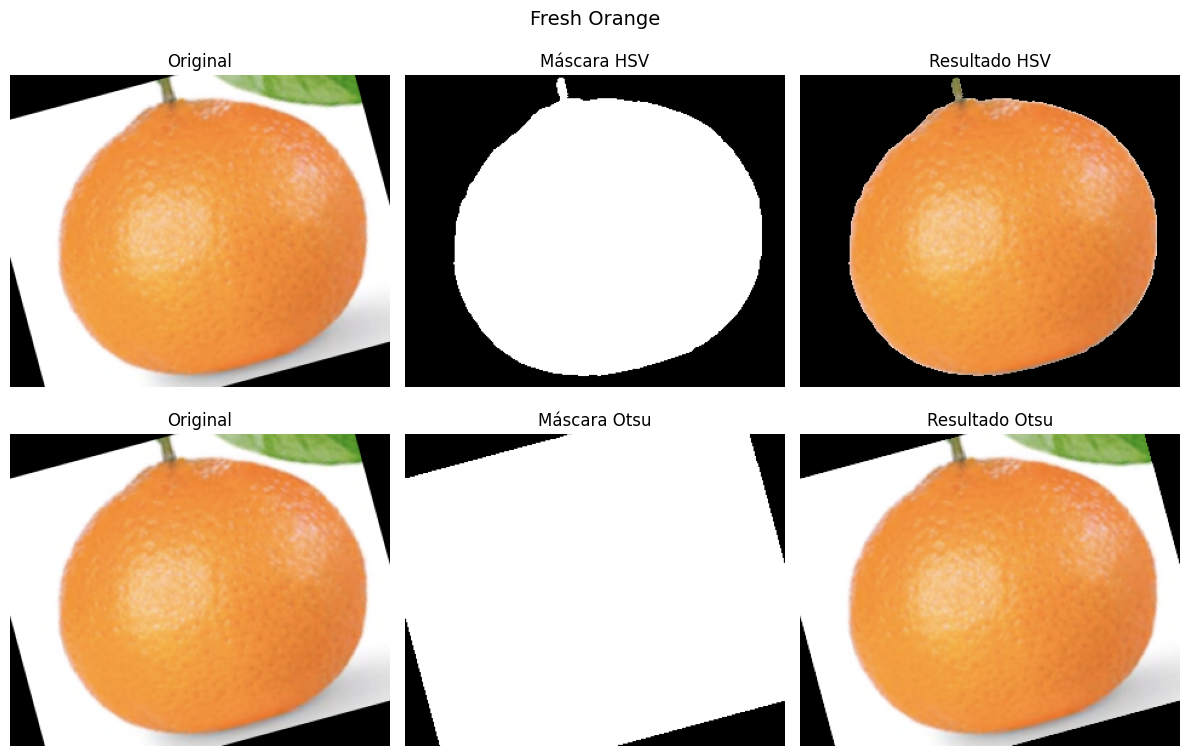

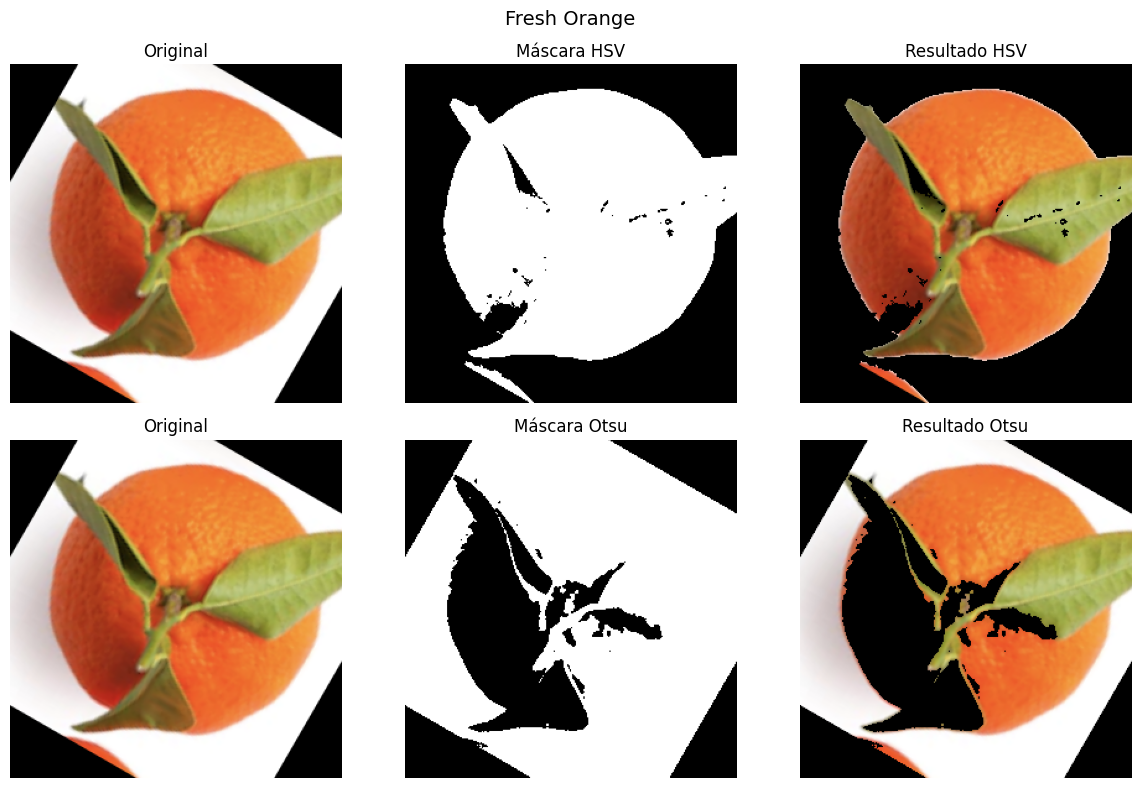

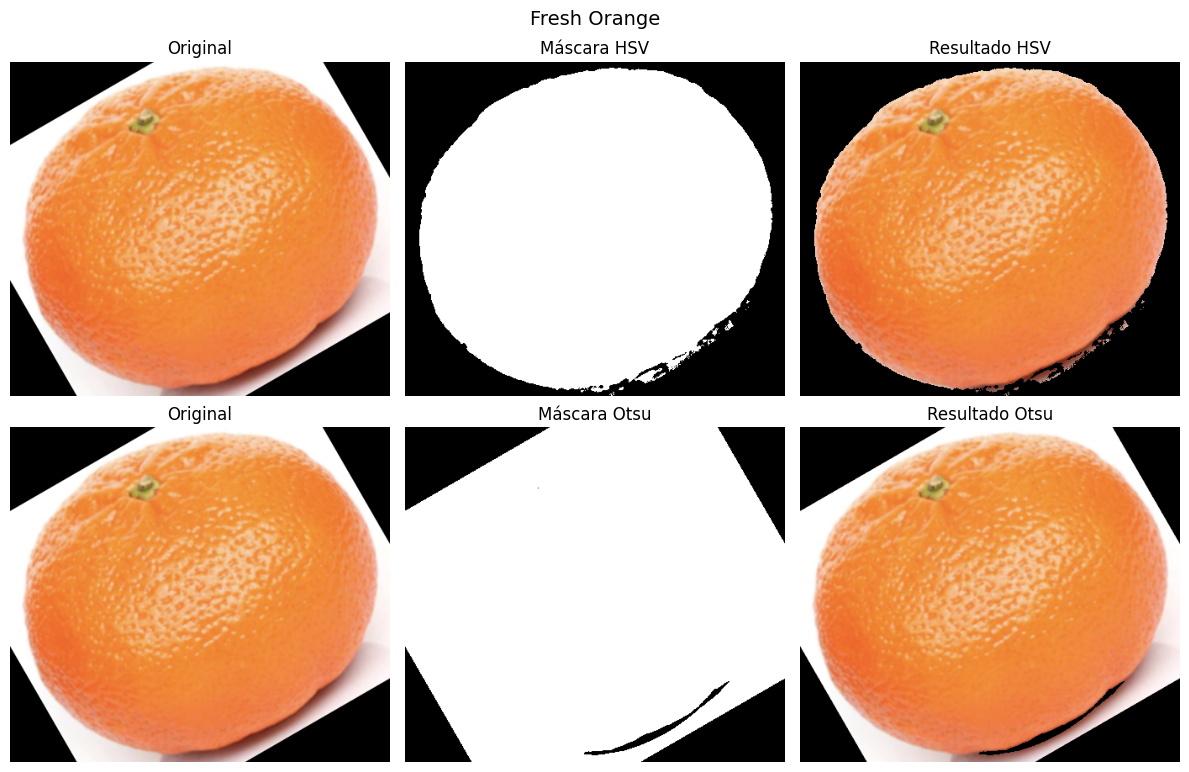

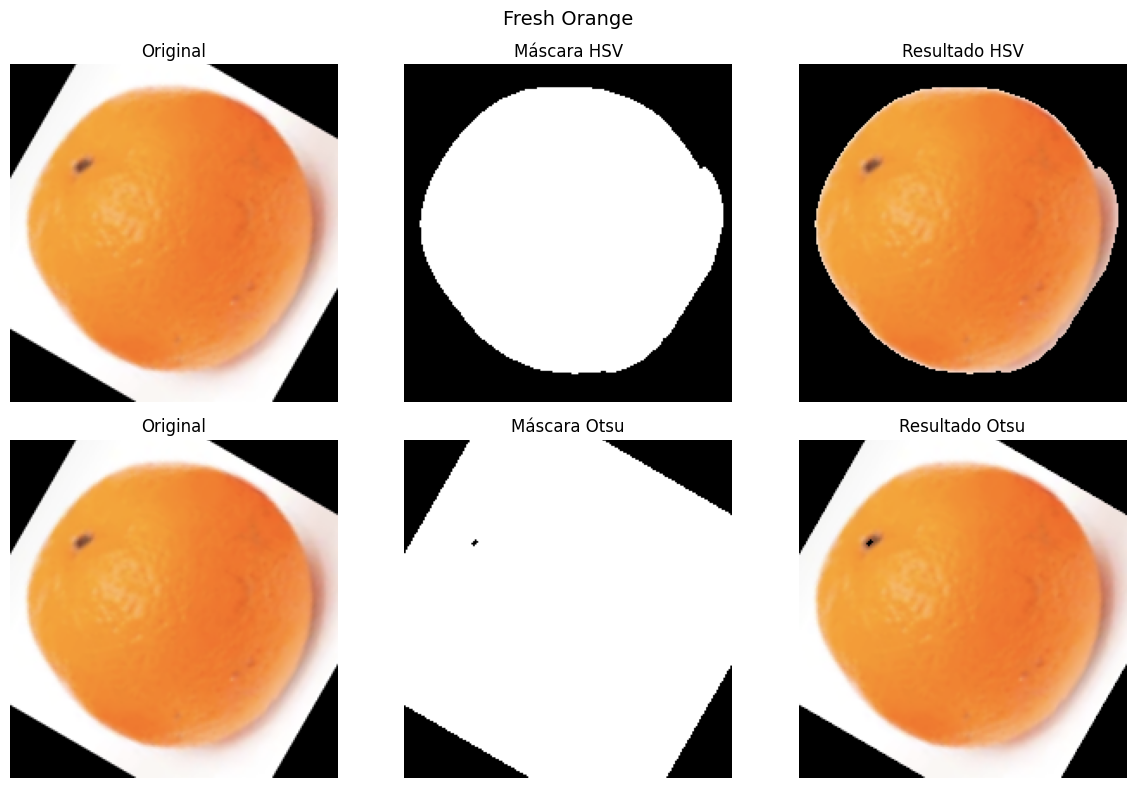

In [21]:
fresh_samples = random.sample(os.listdir(TRAIN_FRESH),5)

for arquivo in fresh_samples:
    img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    compare_segmentation(img,"Fresh Orange")

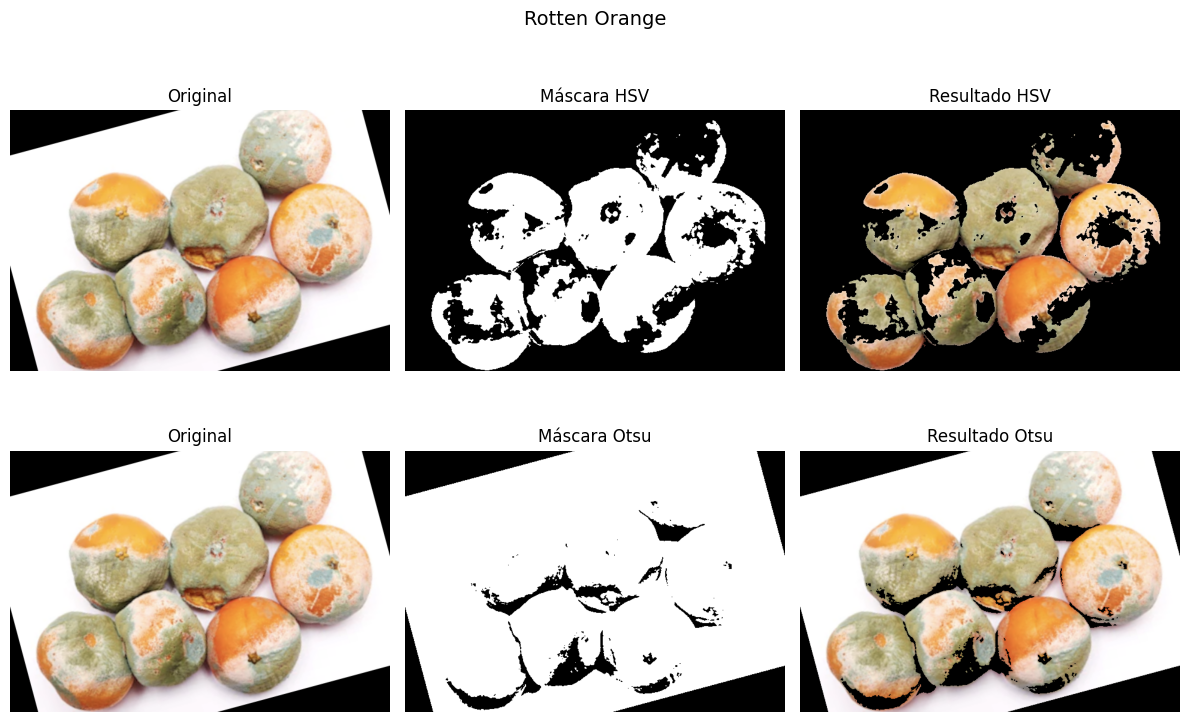

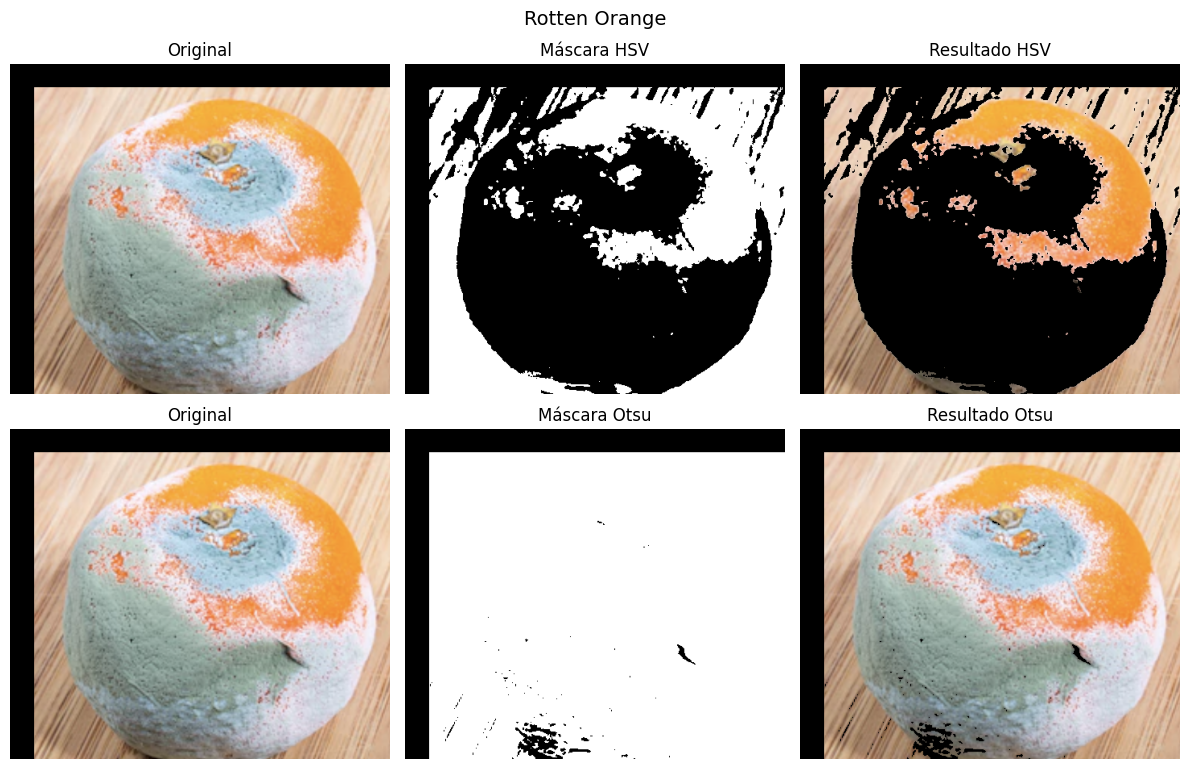

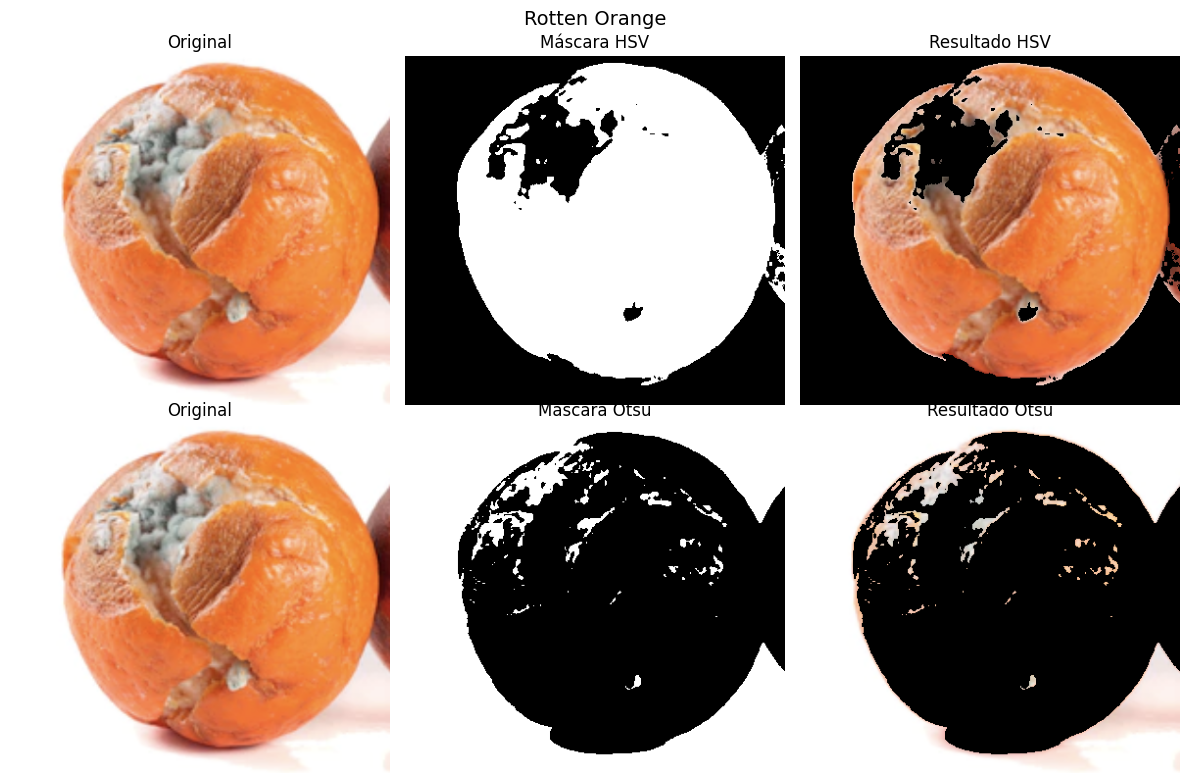

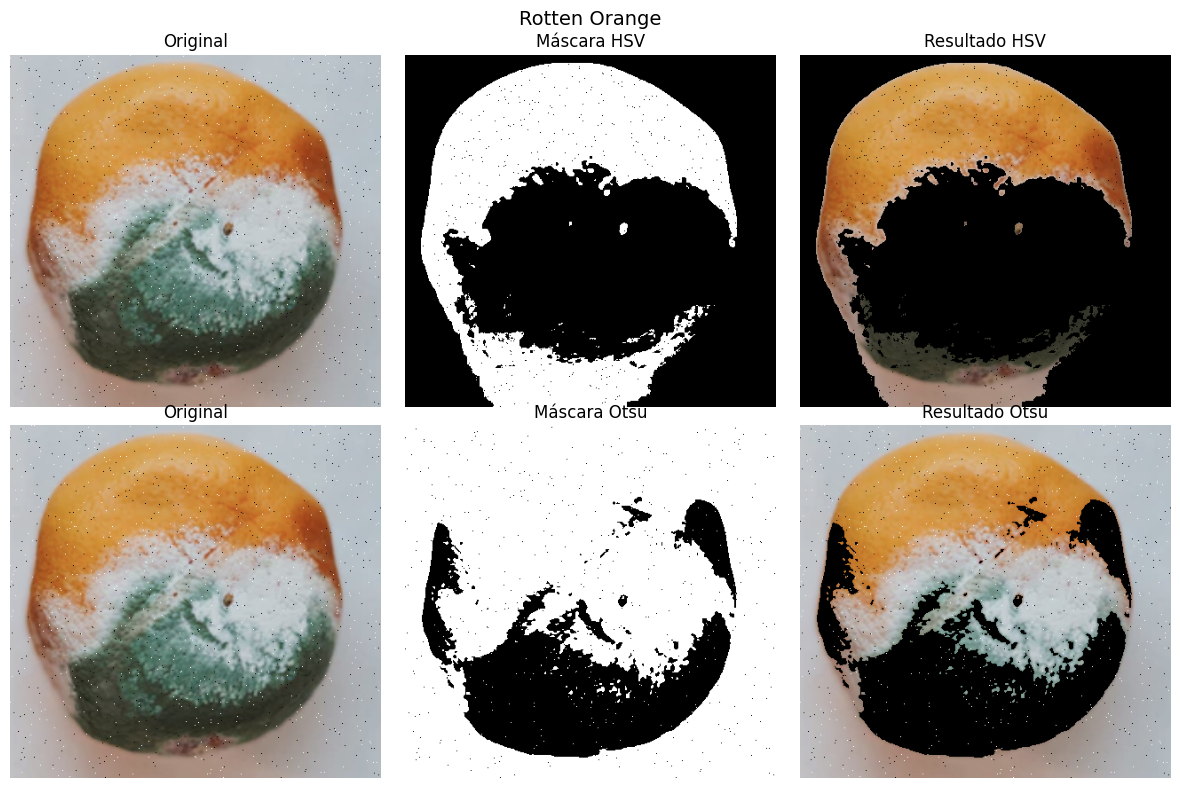

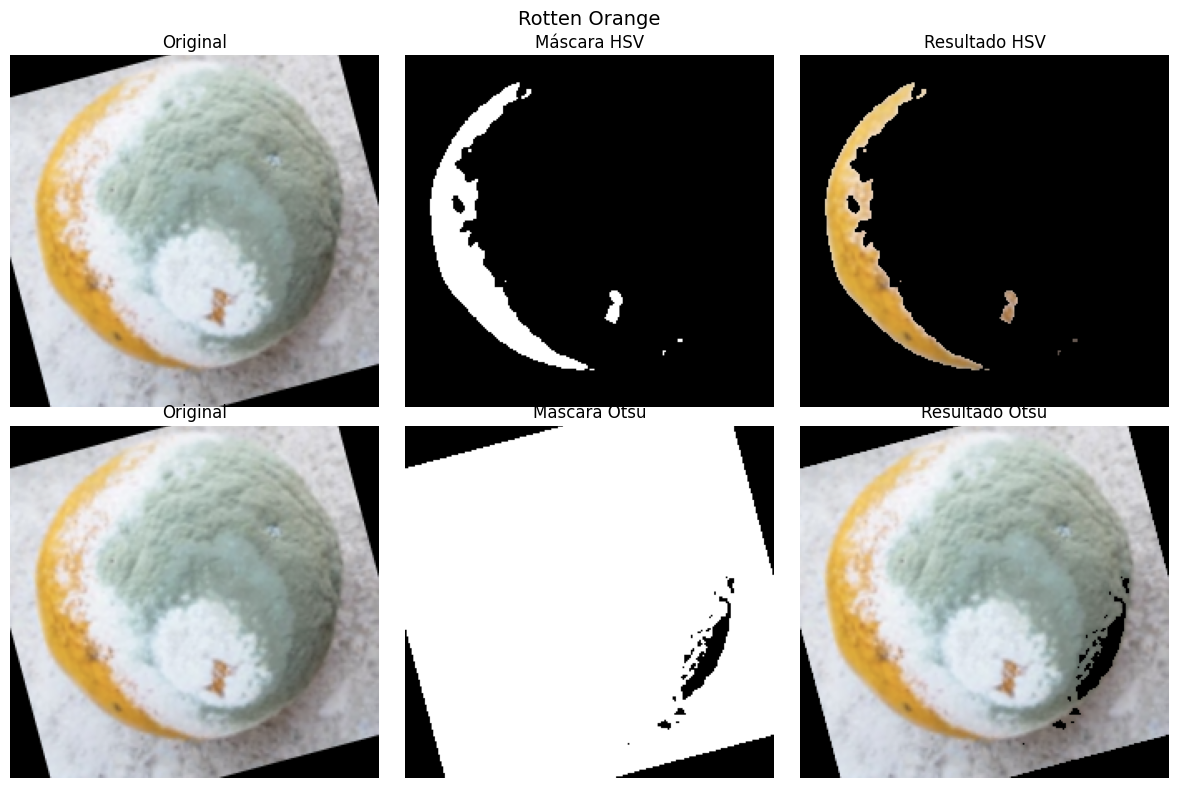

In [22]:
rotten_samples = random.sample(os.listdir(TRAIN_ROTTEN),5)

for arquivo in rotten_samples:
    img = cv2.imread(os.path.join(TRAIN_ROTTEN, arquivo))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    compare_segmentation(img,"Rotten Orange")